In [1]:
#installing required library 
import pandas as pd 
import numpy as np 


In [5]:
#importing data 
df = pd.read_csv('dataset/spam.csv',encoding = 'latin1' )

In [7]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2630,ham,No way I'm going back there!,NaN,NaN,NaN
24,ham,Ffffffffff. Alright no way I can meet up with ...,NaN,NaN,NaN
5375,ham,I cant pick the phone right now. Pls send a me...,NaN,NaN,NaN
1600,ham,K.then any other special?,NaN,NaN,NaN
5362,ham,I'm in inside office..still filling forms.don ...,NaN,NaN,NaN


In [9]:
df.shape

(5572, 5)

# data cleaning 

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [14]:
#dropping unwanted columns from the data...
df = df.drop(columns=(['Unnamed: 2','Unnamed: 3','Unnamed: 4']))

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [16]:
df.sample(5)

,v1,v2
2533,ham,Glad it went well :) come over at 11 then we'l...
5005,ham,ILL B DOWN SOON
83,ham,You will be in the place of that man
3656,ham,Studying. But i.ll be free next weekend.
511,ham,Prabha..i'm soryda..realy..frm heart i'm sory


In [17]:
df.rename(columns = {'v1':'target', 'v2':'text'}, inplace =True)

In [18]:
df.sample(5)

,target,text
60,ham,Your gonna have to pick up a $1 burger for you...
2483,ham,Mm have some kanji dont eat anything heavy ok
3680,ham,LOL what happens in Vegas stays in vegas
835,ham,Good Morning my Dear........... Have a great &...
254,ham,"I'm back, lemme know when you're ready"


In [22]:
from sklearn.preprocessing import LabelEncoder 
encoder = LabelEncoder()

In [24]:
#transforming the data
df['target']=encoder.fit_transform(df['target'])

In [25]:
df.sample(5)

,target,text
5019,0,"It's cool, we can last a little while. Getting..."
3417,1,LIFE has never been this much fun and great un...
1337,0,Then she buying today? ÌÏ no need to c meh...
4896,0,I cant pick the phone right now. Pls send a me...
2551,0,I'm done. C Ì_ there.


In [27]:
#checking for null values...
df.isnull().sum()

target    0
text      0
dtype: int64

In [29]:
#checking for duplicates 
df.duplicated().sum()

403

In [32]:
#removing the duplicates 
df = df.drop_duplicates(keep="first")

In [33]:
#checking after duplicates has been dropped from the data 
df.duplicated().sum()

0

In [35]:
#checking the shapeof the data 
df.shape

(5169, 2)

# EDA

In [37]:
#lets count the value of the data 
df['target'].value_counts()

0    4516
1     653
Name: target, dtype: int64

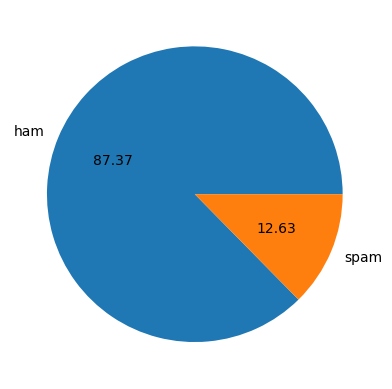

In [49]:
#drawing the pie chart for the dataset 
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(), labels =['ham', 'spam'], autopct= '%0.2f')
plt.show()

<BarContainer object of 2 artists>

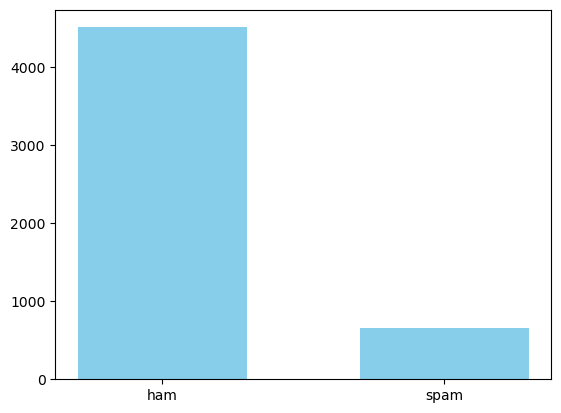

In [54]:
#lets plot the bargrph for the it 
plt.bar(['ham', 'spam'],df['target'].value_counts(), color='skyblue', width =0.6)

In [55]:
#importing nltk 
import nltk

In [57]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/santoshkhatri/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [60]:
#checking the length of the email and adding it to new column 
df['num_character']=df['text'].apply(len)

In [63]:
df.head()

,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [67]:
#counting the number of words in the email and storing in the new column 
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [68]:
df.head()

,target,text,num_character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [73]:
#checking number of sentance used in every email 
df['num_sentance']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [74]:
df.head()

,target,text,num_character,num_words,num_sentance
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [76]:
df[['num_character','num_words','num_sentance']].describe()

,num_character,num_words,num_sentance
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.453279,1.947185
std,58.236293,13.324793,1.362406
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,28.000000


In [79]:
#checking for individual ham 
df[df['target']==0][['num_character','num_words','num_sentance']].describe()
    

,num_character,num_words,num_sentance
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.120903,1.799601
std,56.358207,13.493725,1.278465
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,28.000000


In [80]:
#describing data for spam
df[df['target']==1][['num_character','num_words','num_sentance']].describe()

,num_character,num_words,num_sentance
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.967841
std,30.137753,7.008418,1.483201
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,8.000000


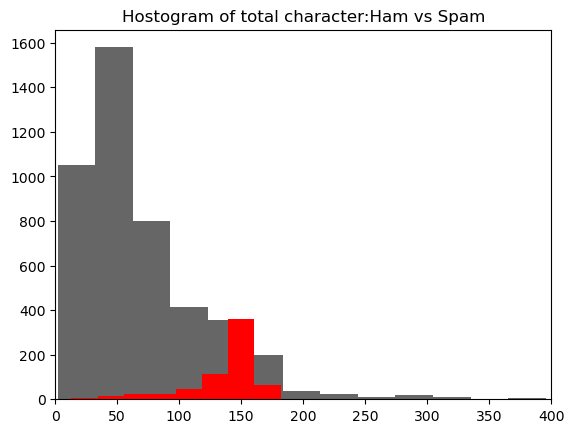

In [91]:
#drawing hiostogram from ham and spam 
plt.hist(df[df['target']==0]['num_character'],bins=30,alpha=0.6,color='black',label ='ham')
plt.hist(df[df['target']==1]['num_character'],color='red')
plt.title('Hostogram of total character:Ham vs Spam')
plt.xlim(0,400)
plt.show()

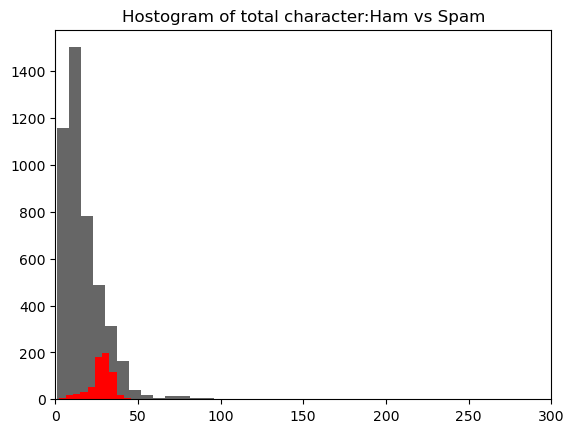

In [93]:
#drawing hiostogram from ham and spam for words 
plt.hist(df[df['target']==0]['num_words'],bins=30,alpha=0.6,color='black',label ='ham')
plt.hist(df[df['target']==1]['num_words'],color='red')
plt.title('Hostogram of total words:Ham vs Spam')
plt.xlim(0,300)
plt.show()

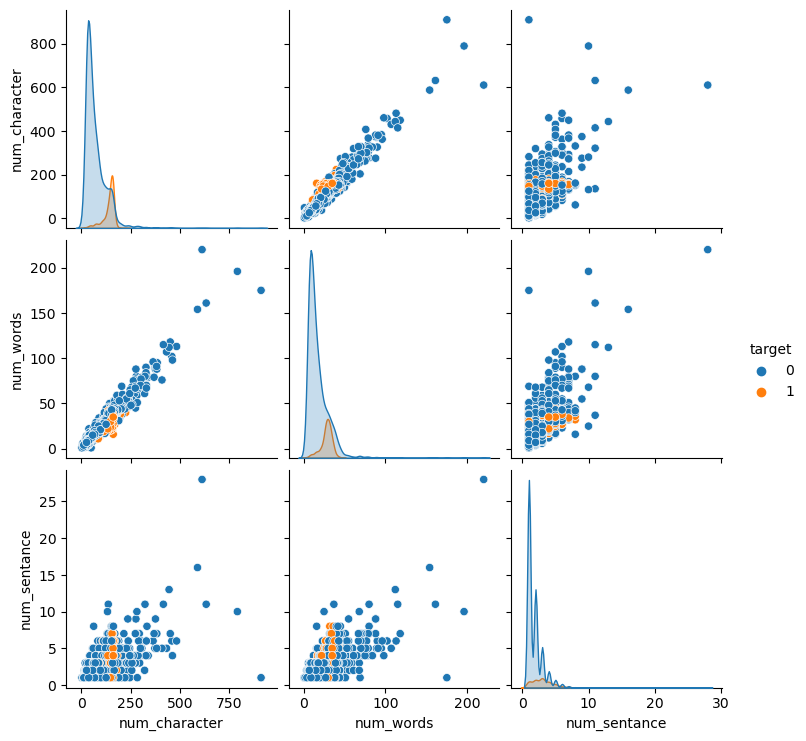

In [97]:
#checking its relation in pairplot 
import seaborn as sns 
sns.pairplot(df,hue="target")
plt.show()

/var/folders/vl/bzb4z1n52mv9g_f37flptljh0000gn/T/ipykernel_83235/1784379384.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot = True)


<Axes: >

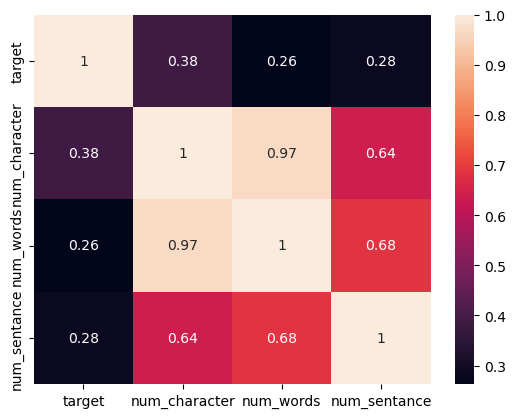

In [104]:
#checking correlation 
sns.heatmap(df.corr(),annot = True)

# data/text prepprocessing 
1.lowercase
2.tokenization
3.removing special character 
4.removing stop words and punctuation 
5.stemming/lemitization


In [125]:
##making function to text preprocessing 
#for checking the stopwords 
from nltk.corpus import stopwords 

import string 
from nltk.stem.porter import PorterStemmer 
ps = PorterStemmer()


def transform_text(text):
    text  = text.lower()  #converting text to lowercase 
    text = nltk.word_tokenize(text)
    
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [129]:
df['transform_text']=df['text'].apply(transform_text)

In [130]:
df.head()

,target,text,num_character,num_words,num_sentance,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [143]:
#making wordcloud 
from wordcloud import WordCloud
wc = WordCloud(width=1500, height =900, min_font_size = 10, background_color = "white")

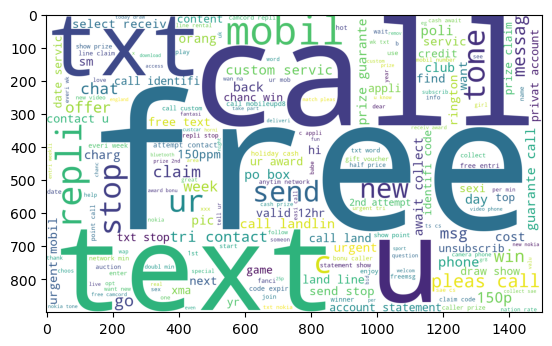

In [144]:
#generating spam wordcloud... 

spam_wc = wc.generate(df[df['target']==1]['transform_text'].str.cat(sep=" "))
plt.imshow(spam_wc)